In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

print("done")

done


In [2]:
sample_size = 1000
X = np.random.normal(0,1,sample_size)
Y = np.random.normal( [2*x +1 for x in X], 0.5, sample_size) + np.random.normal(0, 0.5, sample_size)
Z = np.random.normal( [5*x +1 for x in X], 1, sample_size) + np.random.normal(0, 0.5)


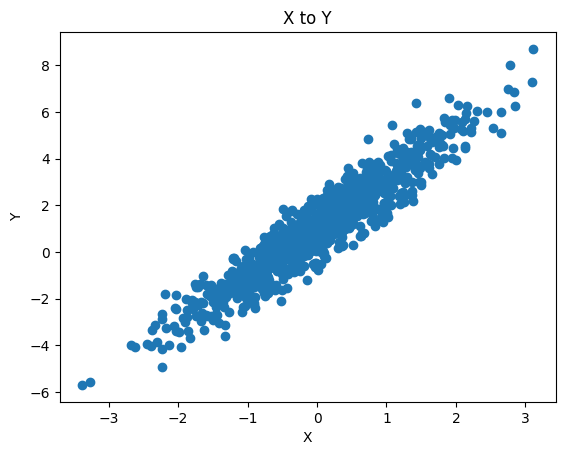

In [3]:
plt.scatter(X,Y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("X to Y")
plt.show()

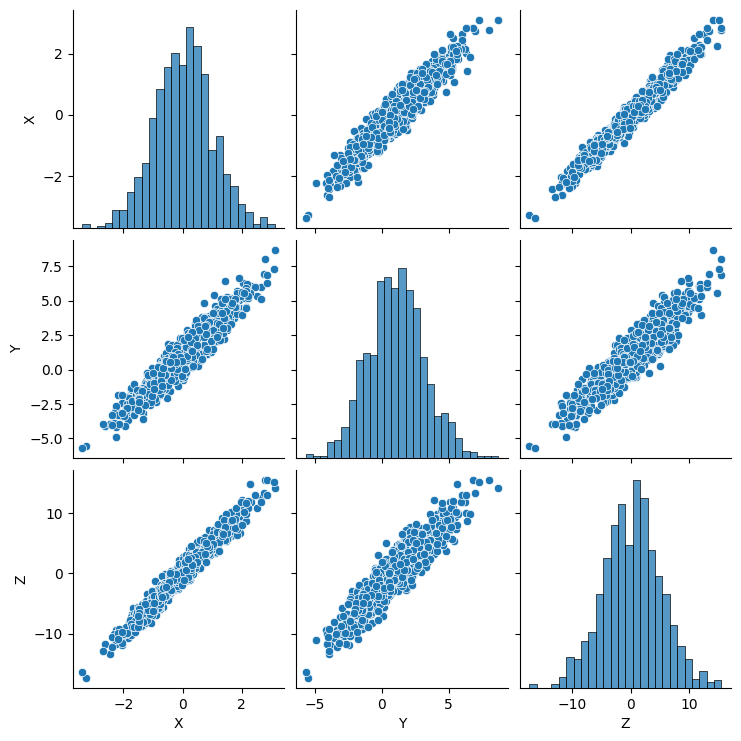

In [18]:
df = pd.DataFrame([X,Y,Z], index=['X','Y', 'Z']).T
sns.pairplot(df)
plt.show()

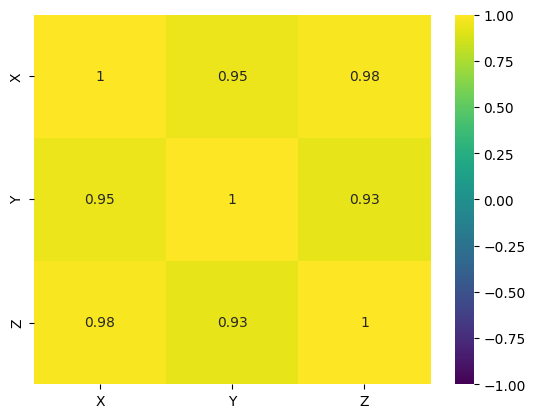

In [23]:
cor = df.corr()
sns.heatmap(cor, cmap='viridis', annot=True, vmin=-1, vmax=1)
plt.show()

In [37]:

def get_residulas(predictor, target):
    model = LinearRegression().fit(predictor.reshape(-1,1), target)
    predictions = model.predict(predictor.reshape(-1,1))
    residuals = target - predictions
    return residuals

res_YbyX = get_residulas(X,Y)
res_ZbyX = get_residulas(X,Z)

res_XbyY = get_residulas(Y,X)
res_ZbyY = get_residulas(Y,Z)

res_XbyZ = get_residulas(Z,X)
res_YbyZ = get_residulas(Z,Y)

print(f"Partial correlation when predictor = X is {np.corrcoef(res_YbyX, res_ZbyX)[0,1]:.4f}")
print(f"Partial correlation when predictor = Y is {np.corrcoef(res_XbyY, res_ZbyY)[0,1]:.4f}")
print(f"Partial correlation when predictor = Z is {np.corrcoef(res_XbyZ, res_YbyZ)[0,1]:.4f}")


Partial correlation when predictor = X is 0.0205
Partial correlation when predictor = Y is 0.8306
Partial correlation when predictor = Z is 0.5093


In [64]:
cov = df.cov()
cov_inv = np.linalg.inv(cov)
cov_inv_scaled = np.zeros_like(cov_inv)
for i in range(len(cov_inv)):
    for j in range(len(cov_inv[0])):
        if i!=j:
            cov_inv_scaled[i,j] = - cov_inv[i,j] / np.sqrt(cov_inv[i,i]*cov_inv[j,j])
        else:
            cov_inv_scaled[i,j]=1

print(cov_inv_scaled)

print(f"Partial correlation when predictor = X is {cov_inv_scaled[1,2]:.4f}")
print(f"Partial correlation when predictor = Y is {cov_inv_scaled[0,2]:.4f}")
print(f"Partial correlation when predictor = Z is {cov_inv_scaled[0,1]:.4f}")

[[1.         0.50929272 0.830581  ]
 [0.50929272 1.         0.02049352]
 [0.830581   0.02049352 1.        ]]
Partial correlation when predictor = X is 0.0205
Partial correlation when predictor = Y is 0.8306
Partial correlation when predictor = Z is 0.5093


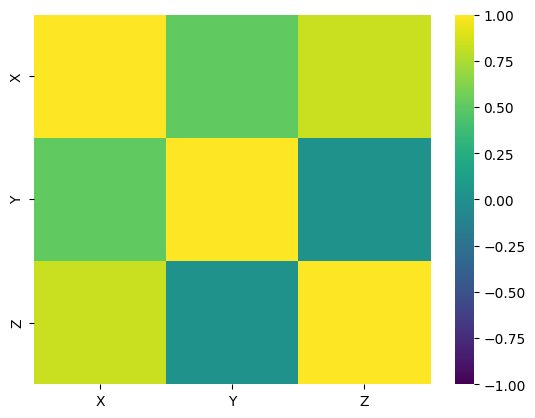

In [69]:
df_partial_corr = pd.DataFrame(cov_inv_scaled, columns=['X','Y','Z'], index=['X','Y','Z'])
sns.heatmap(df_partial_corr, cmap="viridis", vmin=-1, vmax=1)
plt.show()